In [1]:
# @launchit.collected

In [2]:
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]

import sys
import os
from collections import namedtuple # @launchit.collect
from pathlib import Path
import json
import datetime
import pprint
from functools import cache
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import importlib.util

if importlib.util.find_spec('cuml') is not None:
    print('Running with CuML')
    import cuml
    cuml.accel.install(log_level="debug")
else:
    print('Running without CuML')
    
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches
import scipy.io
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import GridSearchCV

import torch
import torch.nn as tnn
import torch.nn.functional as tnnf
import torch.optim as topt
from torch.utils.data import DataLoader, StackDataset
from torchvision import datasets

sys.path.append(project_root_path)
from lib.utils import *
from lib.logging import *
from lib.model_registry import *
import lib.launchit # @launchit.disable
from lib.metrics_collector import RmqSummaryWriter

Running without CuML


# Setup

In [3]:
LOG = Logging()
RNG = np.random.default_rng()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, data_path, mnist_path, metrics_path, ' + 
                    'notebook_fname, notebook_name, is_cuda, cuda_device, is_launch, is_cuml')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    data_path=os.path.join(project_root_path, 'data'),
    mnist_path=os.path.join(project_root_path, 'data', 'mnist'),
    metrics_path=os.path.expanduser('~/tensorboard'),
    notebook_fname='noname.ipynb',
    notebook_name='noname',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    is_launch=False,
    is_cuml=importlib.util.find_spec('cuml') is not None,
)

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)

    m = re.match(r'(\w+)-Copy\d+$', notebook_name)

    if m:
        # Cuml is used to be launched from the copy of the notebook
        notebook_name = m.group(1)
    
    CONFIG = CONFIG._replace(notebook_fname=notebook_fname, notebook_name=notebook_name, is_launch=not re.match(r'\w+-launch\d+$', notebook_name) is None)

print('CONFIG=\n' + pprint.pformat(CONFIG._asdict()))
print('')

# @launchit.disable
# @launchit.collect
MODEL_INSTANCE_INFO = namedtuple('ModelInstanceInfo', 'group_uri, name, version, main_asset_fname')(
    group_uri='${MODEL_GROUP_URI}',
    name='${MODEL_NAME}',
    version=0,
    main_asset_fname='${LAUNCHIT_FNAME}'
)
# @launchit.stop

MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(group_uri=f'{CONFIG.project_root_uri}.{os.path.basename(os.path.dirname(notebook_fname))}')
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(name=CONFIG.notebook_name)
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(main_asset_fname=CONFIG.notebook_fname)
# @launchit.stop

print('MODEL_INSTANCE_INFO=\n' + pprint.pformat(MODEL_INSTANCE_INFO._asdict()))

CONFIG=
{'cuda_device': 'cpu',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'is_cuda': False,
 'is_cuml': False,
 'is_launch': False,
 'metrics_path': '/home/misha/tensorboard',
 'mnist_path': '/home/misha/dev/mine/neurovision/data/mnist',
 'notebook_fname': '/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_07.ipynb',
 'notebook_name': 's3_stacked_dae_07',
 'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision'}

MODEL_INSTANCE_INFO=
{'group_uri': 'com.develorium.neurovision.denoise',
 'main_asset_fname': '/home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_07.ipynb',
 'name': 's3_stacked_dae_07',
 'version': 0}


# Launch

## launchit

In [4]:
# @launchit.disable
launchit_t0 = time.time()

In [46]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    expandvars = dict(
        MODEL_GROUP_URI=MODEL_INSTANCE_INFO.group_uri,
        MODEL_NAME=MODEL_INSTANCE_INFO.name,
    )
    lib.launchit.launchit(CONFIG.notebook_fname, expandvars)
else:
    print('Skip launchit due to mass "Run Cells"')

Creating /home/misha/dev/mine/neurovision/denoise/s3_stacked_dae_07-launch3.ipynb
Cell 0, launchit stanza: "# @launchit.collected"
Cell 1, launchit stanza: "from collections import namedtuple # @launchit.collect"
Cell 1, launchit stanza: "import dataclasses # @launchit.collect"
Cell 1, launchit stanza: "from dataclasses import dataclass # @launchit.collect"
Cell 1, launchit stanza: "import lib.launchit # @launchit.disable"
Cell 3, launchit stanza: "# @launchit.disable"
Cell 3, launchit stanza: "# @launchit.collect"
Cell 3, launchit stanza: "# @launchit.stop"
Cell 3, command COLLECT at line 36 will stop at line 43
Cell 3, launchit stanza: "# @launchit.stop"
Cell 3, command DISABLE at line 35 will stop at line 48
Cell 5, launchit stanza: "# @launchit.disable"
Cell 6, launchit stanza: "# @launchit.disable"
Cell 8, launchit stanza: "# @launchit.disable"
Cell 8, launchit stanza: "# @launchit.collect"
Cell 10, launchit stanza: "# @launchit.disable"
Cell 10, launchit stanza: "# @launchit.coll

## new_model_registry

In [15]:
def new_model_registry(is_real=None):
    is_real = is_real if is_real is not None else CONFIG.is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(MODEL_INSTANCE_INFO.group_uri)

## new_summary_writer

In [16]:
def new_summary_writer(log_dir, is_real=None):
    is_real = is_real if is_real is not None else CONFIG.is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## Bootstrap launch

In [17]:
model_registry = new_model_registry(is_real=None)
new_model_instance_version = model_registry.register_model(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.main_asset_fname)
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=new_model_instance_version)
print(f'Model instance registered, version={MODEL_INSTANCE_INFO.version}')

meta = dict(hypers=HP._asdict(), config=CONFIG._asdict())

with io.StringIO() as b:
    json.dump(meta, b)
    model_registry.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'meta', replace=True)

summary_log_dir = os.path.join(MODEL_INSTANCE_INFO.name, str(MODEL_INSTANCE_INFO.version))
print(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict()), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict()), 1)

Model instance registered, version=0
Tensorboard run=s3_stacked_dae_07/0


<Mock name='mock.add_text()' id='139283751778736'>

# Hyperparameters

In [6]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    @dataclass
    class Images:
        preprocessing: str = None
        
    @dataclass
    class PretrainModel:
        daes_count: int = None
        filters_count: int = None
        is_tied_weights: bool = None
        is_bias: bool = None
        nonlinearity: dict = None

    @dataclass
    class Pretraining:
        batch_size: int = None
        epochs_count: int = None
        optimizer: str = None
        learn_rate: float = None
        noise: str = None
        loss: str = None
        regularization: dict = None

    @dataclass
    class Training:
        batch_size: int = None
        epochs_count: int = None
        optimizer: str = None
        learn_rate: float = None
        
    images: Images = dataclasses.field(default_factory=Images)
    pretrain_model: PretrainModel = dataclasses.field(default_factory=PretrainModel)
    pretraining: Pretraining = dataclasses.field(default_factory=Pretraining)
    training: Training = dataclasses.field(default_factory=Training)

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        hp.images = Images(**hp.images)
        hp.pretrain_model = PretrainModel(**hp.pretrain_model)
        hp.pretraining = Pretraining(**hp.pretraining)
        hp.training = Training(**hp.training)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()

# Images

In [7]:
# @launchit.disable
# @launchit.collect
HP.images.preprocessing = 'UNINORM' # NONE, UNINORM, MIN_MAX, STANDARDIZE, ZCA_WHITEN, ZCA_HFR30_WHITEN

## get_mnist_images

In [58]:
def get_mnist_images(subdataset='TRAIN'):
    assert subdataset in ['TRAIN', 'TEST'], f'Unsupported subdataset={subdataset}'
    d = datasets.MNIST(CONFIG.mnist_path, train=subdataset=='TRAIN', download=True)
    images = d.data.reshape(len(d.data), -1)
    images = images.numpy()
    images = images.astype('float32')
    image_labels = d.targets
    return images, image_labels

## UninormScaler

In [9]:
class UninormScaler:
    def __init__(self, divisor=255.0):
        self.divisor = divisor
        
    def fit_transform(self, images):
        return self.transform(images)

    def transform(self, images):
        return images / self.divisor

## preprocess_images

In [10]:
def preprocess_images(images, preprocessing_method, scaler=None):
    match preprocessing_method:
        case 'UNINORM':
            scaler = UninormScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'MIN_MAX':
            scaler = MinMaxScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'STANDARDIZE':
            scaler = StandardScaler() if scaler is None else scaler
            images = scaler.fit_transform(images)
        case 'ZCA_WHITEN':
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
            
            Σ = np.cov(images, rowvar=False)
            u, s, _ = np.linalg.svd(Σ)
            images = (u @ np.diag(1.0 / np.sqrt(s + 1e-6)) @ u.T @ images.T).T
        case 'ZCA_HFR30_WHITEN': # HFR30 - Remove 30% of High Frequencies
            scaler = StandardScaler(with_std=False) if scaler is None else scaler
            images = scaler.fit_transform(images)
    
            Σ = np.cov(images, rowvar=False)
            eigvals, eigvecs = np.linalg.eig(Σ)
            eigvals_order = np.argsort(-eigvals)
            wipeout_inds = eigvals_order[int(len(eigvals_order) * (1 - 0.3)):]
            eigvals_w = eigvals.copy()
            eigvals_w[wipeout_inds] = 0
            
            R, S = eigvecs, np.diag(np.sqrt(eigvals_w)) # R - rotation matrix, S - scale matrix
            S_inv = np.reciprocal(S, out=np.zeros_like(S), where=(S != 0))
            R_inv = R.T
            W = R @ S_inv @ R_inv  # equiv. to: R @ np.eye(len(S_inv)) @ S_inv @ R_inv
            images = (W @ images.T).T
        case 'NONE':
            pass
        case _:
            assert False, f'Unsupported preprocessing_method={preprocessing_method}'

    return images, scaler

# Noising

## gauss_noise

In [11]:
def gauss_noise(items, gadds_tab):
    if items.ndim == 2:
        assert items.shape[1] == gadds_tab.shape[1], f'Shape mismatch: {items.shape[1]} vs {gadds_tab.shape[1]}'
        items_count = len(items)
        noise = gadds_tab[RNG.choice(len(gadds_tab), items_count)]
    elif items.ndim == 1:
        gadd_ind = RNG.choice(len(gadds_tab))
        noise = gadds_tab[gadd_ind]
    else:
        assert False, f'Unsupported dimensions count for items: {items.ndim}'

    if isinstance(items, np.ndarray):
        return items + noise
    elif isinstance(items, torch.Tensor):
        return items + torch.tensor(noise, device=items.device, dtype=items.dtype)

## masking_noise

In [12]:
def masking_noise(items, masks_tab, fill_value=0):
    if items.ndim == 2:
        assert items.shape[1] == masks_tab.shape[1], f'Shape mismatch: {items.shape[1]} vs {masks_tab.shape[1]}'
        items_count = len(items)
        mask_inds = RNG.choice(len(masks_tab), items_count, replace=False)
        boolmap = masks_tab[mask_inds]
    elif items.ndim == 1:
        mask_ind = RNG.choice(len(masks_tab))
        boolmap = masks_tab[mask_ind]
    else:
        assert False, f'Unsupported dimensions count for items: {items.ndim}'

    if isinstance(items, np.ndarray):
        noised = items.copy()
    elif isinstance(items, torch.Tensor):
        noised = items.clone()
    else:
        assert False, f'Unsupported type(items): {type(items)}'

    noised[boolmap] = fill_value
    return noised

## generate_zmasks

In [13]:
def generate_zmasks(ν, item_size, count):
    assert 0 <= ν <= 1
    zero_inds_count = int(ν * item_size)
    zmasks = np.full((count, item_size), False)
    
    for i in range(count):
        zero_inds = RNG.choice(item_size, zero_inds_count, replace=False)
        zmasks[i,zero_inds] = True

    return zmasks    

## Demo

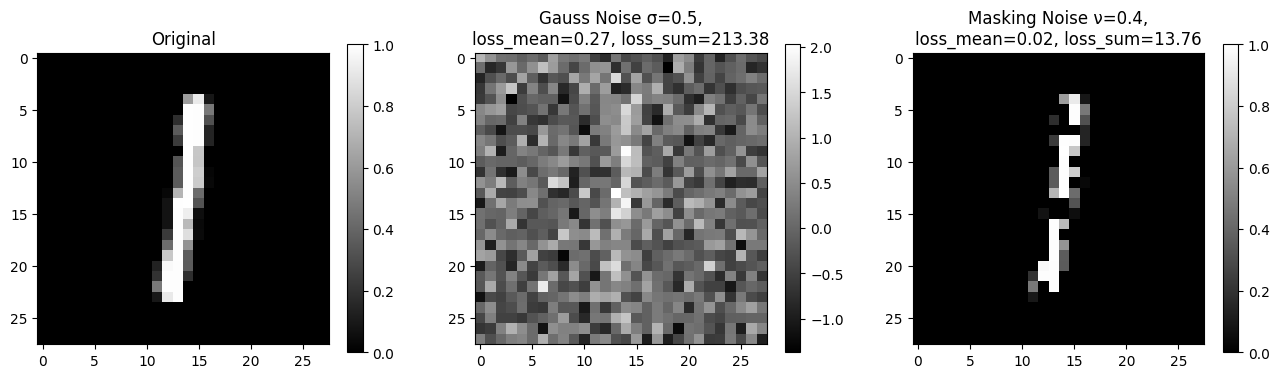

In [14]:
# @launchit.disable
images, _ = get_mnist_images()
images, _ = preprocess_images(images, HP.images.preprocessing)
image_ind = RNG.choice(len(images))
image = images[image_ind]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.set_title('Original')
im = ax1.imshow(ArrayUtils.v2sm(image), cmap='gray');
fig.colorbar(im, ax=ax1, shrink=.5)

σ = 0.5
gadds = RNG.normal(0, σ, (100, image.shape[0]))
noised = gauss_noise(image.ravel(), gadds)
noised = noised.reshape(image.shape)
ax2.set_title(f'Gauss Noise σ={σ},\nloss_mean={((image - noised)**2).mean():.2f}, loss_sum={((image - noised)**2).sum():.2f}')
im = ax2.imshow(ArrayUtils.v2sm(noised), cmap='gray');
fig.colorbar(im, ax=ax2, shrink=.5)

ν = 0.4
zmasks = generate_zmasks(ν, image.shape[0], 100)
noised = masking_noise(image.ravel(), zmasks, fill_value=0)
noised = noised.reshape(image.shape)
ax3.set_title(f'Masking Noise ν={ν},\nloss_mean={((image - noised)**2).mean():.2f}, loss_sum={((image - noised)**2).sum():.2f}')
im = ax3.imshow(ArrayUtils.v2sm(noised), cmap='gray');
fig.colorbar(im, ax=ax3, shrink=.5);

# Unsupervised pretraining

## Dataset

In [47]:
pretrain_dataset, _ = get_mnist_images('TRAIN')
pretrain_dataset, _ = preprocess_images(pretrain_dataset, HP.images.preprocessing)
pretrain_dataset = torch.Tensor(pretrain_dataset)
pretrain_dataset = pretrain_dataset.contiguous() # force dense memory layout (speeds up DataLoader x2)

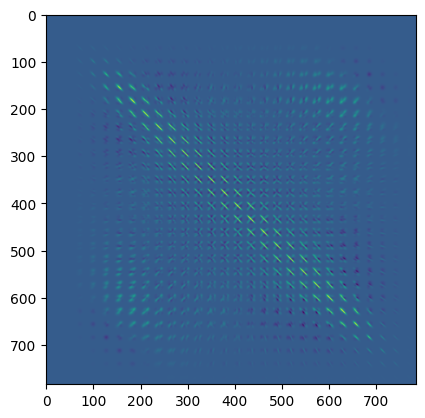

In [48]:
# @launchit.disable
plt.imshow(np.cov(pretrain_dataset, rowvar=False));

## Model: StackedDAE

In [49]:
class DenoiseAutoencoder(tnn.Module):
    def __init__(self, inp_dims_count, model_hp):
        super().__init__()
        self.encoder = tnn.Linear(inp_dims_count, model_hp.filters_count, bias=model_hp.is_bias) # aka filters
        # all weights are initialized by default via init.kaiming_uniform_ 

        if model_hp.is_tied_weights:
            self.decoder = None
            self.decoder_bias = tnn.Parameter(torch.randn(inp_dims_count)) if model_hp.is_bias else None
        else:
            self.decoder = tnn.Linear(model_hp.filters_count, inp_dims_count, bias=model_hp.is_bias)
            self.decoder_bias = None

        nonlinearities = {None: lambda x: x, 'sigmoid': tnnf.sigmoid}
        nonlinearity = {} if model_hp.nonlinearity is None else model_hp.nonlinearity
        self.encoder_nonlinearity = nonlinearities[nonlinearity.get('encoder', None)]
        self.decoder_nonlinearity = nonlinearities[nonlinearity.get('decoder', None)]

    def forward(self, inp):
        encoded = self.encode(inp)
        decoded = self.decode(encoded)
        return decoded, encoded

    def encode(self, inp):
        return self.encoder_nonlinearity(self.encoder(inp))

    def decode(self, inp):
        if self.decoder is None:
            # tied weights
            res = tnnf.linear(inp, self.encoder.weight.t(), self.decoder_bias)
        else:
            res = self.decoder(inp)
            
        return self.decoder_nonlinearity(res) 

class StackedDAE(tnn.Module):
    def __init__(self, inp_dims_count, model_hp):
        super().__init__()
        self.daes = tnn.ModuleList()

        current_inp_dims_count = inp_dims_count
        
        for i in range(model_hp.daes_count):
            dae = DenoiseAutoencoder(current_inp_dims_count, model_hp)
            current_inp_dims_count = model_hp.filters_count
            self.daes.append(dae)

    def encode(self, inp, daes_count=-1):
        daes_count = len(self.daes) if daes_count == -1 else daes_count
        
        for i in range(0, daes_count):
            dae = self.daes[i]
            inp = dae.encode(inp)

        return inp

In [50]:
model_hp = Hyperparameters.PretrainModel(daes_count=3, filters_count=1000, is_tied_weights=True, is_bias=True, nonlinearity={'encoder': 'sigmoid', 'decoder': None})
pretrain_model = StackedDAE(pretrain_dataset.shape[1], model_hp)
sum([p.numel() for p in pretrain_model.parameters()])

2789784

In [51]:
data_loader = DataLoader(pretrain_dataset, batch_size=100)
batch = next(iter(data_loader))

# ascention stage
with torch.no_grad():
    for i in range(len(pretrain_model.daes)):
        save_shape = batch.shape
        batch = pretrain_model.daes[i].encode(batch)
        print(f'Encoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')

# descention stage
with torch.no_grad():
    for i in reversed(range(len(pretrain_model.daes))):
        save_shape = batch.shape
        batch = pretrain_model.daes[i].decode(batch)
        print(f'Decoding by DAE_{i}, batch shape={save_shape}->{batch.shape}')    

Encoding by DAE_0, batch shape=torch.Size([100, 784])->torch.Size([100, 1000])
Encoding by DAE_1, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Encoding by DAE_2, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Decoding by DAE_2, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Decoding by DAE_1, batch shape=torch.Size([100, 1000])->torch.Size([100, 1000])
Decoding by DAE_0, batch shape=torch.Size([100, 1000])->torch.Size([100, 784])


## Pretraining

In [23]:
@cache
def gadds(σ, item_size, gadds_count):
    return RNG.normal(0, σ, (gadds_count, item_size)).astype(float) 

@cache
def zmasks(ν, item_size, masks_count):
    return generate_zmasks(ν, item_size, masks_count)

In [24]:
optimizers = {
    'SGD': lambda parameters, lr: topt.SGD(parameters, lr),
    'Adam': lambda parameters, lr: topt.Adam(parameters, lr),
}

noise_funcs = {
    'Gauss_0.5': lambda items: gauss_noise(items, gadds(0.5, items.shape[1], 250_000)),
    'Masking_0': lambda items: masking_noise(items, zmasks(0, items.shape[1], 250_000)),
    'Masking_0.1': lambda items: masking_noise(items, zmasks(0.1, items.shape[1], 250_000)),
    'Masking_0.25': lambda items: masking_noise(items, zmasks(0.25, items.shape[1], 250_000)),
    'Masking_0.25_1': lambda items: masking_noise(items, zmasks(0.25, items.shape[1], 250_000), fill_value=1),
    'Masking_0.3': lambda items: masking_noise(items, zmasks(0.3, items.shape[1], 250_000)),
    'Masking_0.4': lambda items: masking_noise(items, zmasks(0.4, items.shape[1], 250_000)),
    'Masking_0.55': lambda items: masking_noise(items, zmasks(0.55, items.shape[1], 250_000)),
    'Masking_0.6': lambda items: masking_noise(items, zmasks(0.6, items.shape[1], 250_000)),
}

losses = {
    # sigmoid is expected to be withing Model structure (decoder)
    'BCE': lambda: tnn.BCELoss(reduction='mean'), 
    # sigmoid is NOT expected to be within Model structure, since sigmoid is builtin into loss itself
    'BCEWithLogits': lambda: tnn.BCEWithLogitsLoss(reduction='mean'), 
    ### 
    'MSE_mean': lambda: tnn.MSELoss(reduction='mean'),
}

regularizations = {
    # Over activations acting regularizers
    'log(1+a^2)': lambda a: torch.log(1 + a**2), # Olshausen (sparsenet)
    '|a|': lambda a: torch.abs(a), # L1 regularization
}

# @launchit.disable
# @launchit.collect
HP.pretrain_model.daes_count = 3
HP.pretrain_model.filters_count = 1_000
HP.pretrain_model.is_tied_weights = True
HP.pretrain_model.is_bias = True
HP.pretrain_model.nonlinearity = {'encoder': 'sigmoid', 'decoder': 'sigmoid'}

HP.pretraining.batch_size = 1_000
HP.pretraining.epochs_count = 500
HP.pretraining.noise = 'Masking_0.4'
HP.pretraining.optimizer = 'Adam'
HP.pretraining.learn_rate = 0.01
HP.pretraining.loss = 'BCE'
HP.pretraining.regularization = None
# @launchit.stop
pprint.pprint(HP._asdict())

{'images': {'preprocessing': 'UNINORM'},
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 500,
                 'learn_rate': 0.01,
                 'loss': 'BCE',
                 'noise': 'Masking_0.4',
                 'optimizer': 'Adam',
                 'regularization': None},
 'training': {'batch_size': None,
              'epochs_count': None,
              'learn_rate': None,
              'optimizer': None}}


In [25]:
def compute_regularized_loss(inferred, target, activations, loss_fn, regularization):
    loss = loss_fn(inferred, target) # args order: input, target

    if regularization is not None and regularization['c'] > 0:
        c = regularization['c']
        reg_fn = regularizations[regularization['fn']]
        loss += c * reg_fn(activations)
    
    return loss

In [26]:
# pt_data = model_registry.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, 'pretrain')
# pt_data = io.BytesIO(initial_bytes=pt_data)
# checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
# pretrain_model.load_state_dict(checkpoint['model_state_dict'])
# # optimizer.load_state_dict(checkpoint['optimizer_state_dict']) # TODO dictinct optimizer instances are used for distinct DAE, adapt this code if needed
# epoch = int(checkpoint['epoch'])
# print(f'Model instance loaded from version={MODEL_INSTANCE_INFO.version}, epoch={epoch}')

In [27]:
data_loader = DataLoader(pretrain_dataset, batch_size=HP.pretraining.batch_size, pin_memory=CONFIG.is_cuda, shuffle=True)
pretrain_model = StackedDAE(pretrain_dataset.shape[1], HP.pretrain_model)
pretrain_model = pretrain_model.to(device=CONFIG.cuda_device)
noise_func = noise_funcs[HP.pretraining.noise]
loss_fn = losses[HP.pretraining.loss]()
pretrain_model.train()
example_item_ind = RNG.choice(len(pretrain_dataset))

In [ ]:
for trained_dae_ind in tqdm(range(len(pretrain_model.daes)), 'DAE'):
    optimizer = optimizers[HP.pretraining.optimizer](pretrain_model.parameters(), lr=HP.pretraining.learn_rate)
    
    for epoch_ind in tqdm(range(HP.pretraining.epochs_count), 'Epoch'):
        local_epoch = epoch_ind + 1
        global_epoch = HP.pretraining.epochs_count * trained_dae_ind + local_epoch
        
        loss_train = 0
        
        for batch in data_loader:
            optimizer.zero_grad()
            
            batch = batch.to(device=CONFIG.cuda_device)
    
            with torch.no_grad():
                assert 0 <= trained_dae_ind < len(pretrain_model.daes)
    
                for i in range(trained_dae_ind):
                    batch = pretrain_model.daes[i].encode(batch)
    
            noised = noise_func(batch)
            reconstructed, activations = pretrain_model.daes[trained_dae_ind](noised)
    
            loss = compute_regularized_loss(reconstructed, batch, activations, loss_fn, HP.pretraining.regularization)
            loss.backward()
            
            optimizer.step()
            
            loss_train += loss.item() * len(batch)
        
        summary_writer.add_scalar('pretrain_loss', loss_train / len(data_loader), global_epoch)
        summary_writer.add_scalar(f'pretrain_loss_{trained_dae_ind}', loss_train / len(data_loader), local_epoch)
    
        if (epoch_ind % 20) == 0:
            # Examples -> tensorboard            
            with torch.no_grad():
                fig, (ax1, ax2, ax3) = plt.subplots(1, 3, subplot_kw={'yticks': [], 'xticks': []})
                fig.set_figwidth(13)
                fig.set_figheight(4)
                
                batch = pretrain_dataset[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
                
                for i in range(trained_dae_ind):
                    batch = pretrain_model.daes[i].encode(batch)
                
                noised = noise_func(batch)
                reconstructed, activations = pretrain_model.daes[trained_dae_ind](noised)
                reconstructed = reconstructed.to(device='cpu').detach()
                noised = noised.to(device='cpu').detach()
                
                batch = batch.to(device='cpu')
                
                im = ax1.imshow(ArrayUtils.v2sm(batch.numpy().ravel(), 0))
                fig.colorbar(im, ax=ax1)
                im = ax2.imshow(ArrayUtils.v2sm(noised.numpy().ravel(), 0))
                fig.colorbar(im, ax=ax2)
                im = ax3.imshow(ArrayUtils.v2sm(reconstructed.numpy().ravel(), 0))
                fig.colorbar(im, ax=ax3)
                loss1 = compute_regularized_loss(batch, batch, activations, loss_fn, HP.pretraining.regularization)
                loss2 = compute_regularized_loss(noised, batch, activations, loss_fn, HP.pretraining.regularization)
                loss3 = compute_regularized_loss(reconstructed, batch, activations, loss_fn, HP.pretraining.regularization)
                fig.suptitle(f'DAE {trained_dae_ind}, Loss Input/Noised/Reconstr.={loss1:.3f} / {loss2:.3f} / {loss3:.3f}');
                fig.tight_layout()
                summary_writer.add_figure(f'pretrain_example_{trained_dae_ind}', fig, local_epoch, close=True)
            
        if (epoch_ind % 20) == 0 and trained_dae_ind == 0:
            # Filters (first DAE only) -> tensorboard
            bases_in_row = 10
            max_filters_to_show = 100
            fig, axes = plt.subplots(
                int(np.ceil(min(max_filters_to_show, pretrain_model.daes[0].encoder.out_features) / bases_in_row)), 
                bases_in_row,
                subplot_kw={'yticks': [], 'xticks': []}
            )
            fig.set_figwidth(12)
            fig.set_figheight(18)
            filters = pretrain_model.daes[0].encoder.weight.to(device='cpu').detach()
            
            for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
                ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
                ax.imshow(ArrayUtils.v2sm(f), cmap='gray')
            
            fig.tight_layout()
            summary_writer.add_figure(f'pretrain_filters_{trained_dae_ind}', fig, local_epoch, close=True)
        
        summary_writer.flush()

In [32]:
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': pretrain_model.state_dict(),
        # 'optimizer_state_dict': optimizer.state_dict(), # TODO dictinct optimizer instances are used for distinct DAE, adapt this code if needed
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'pretrain_pt', replace=True)

## Visualization

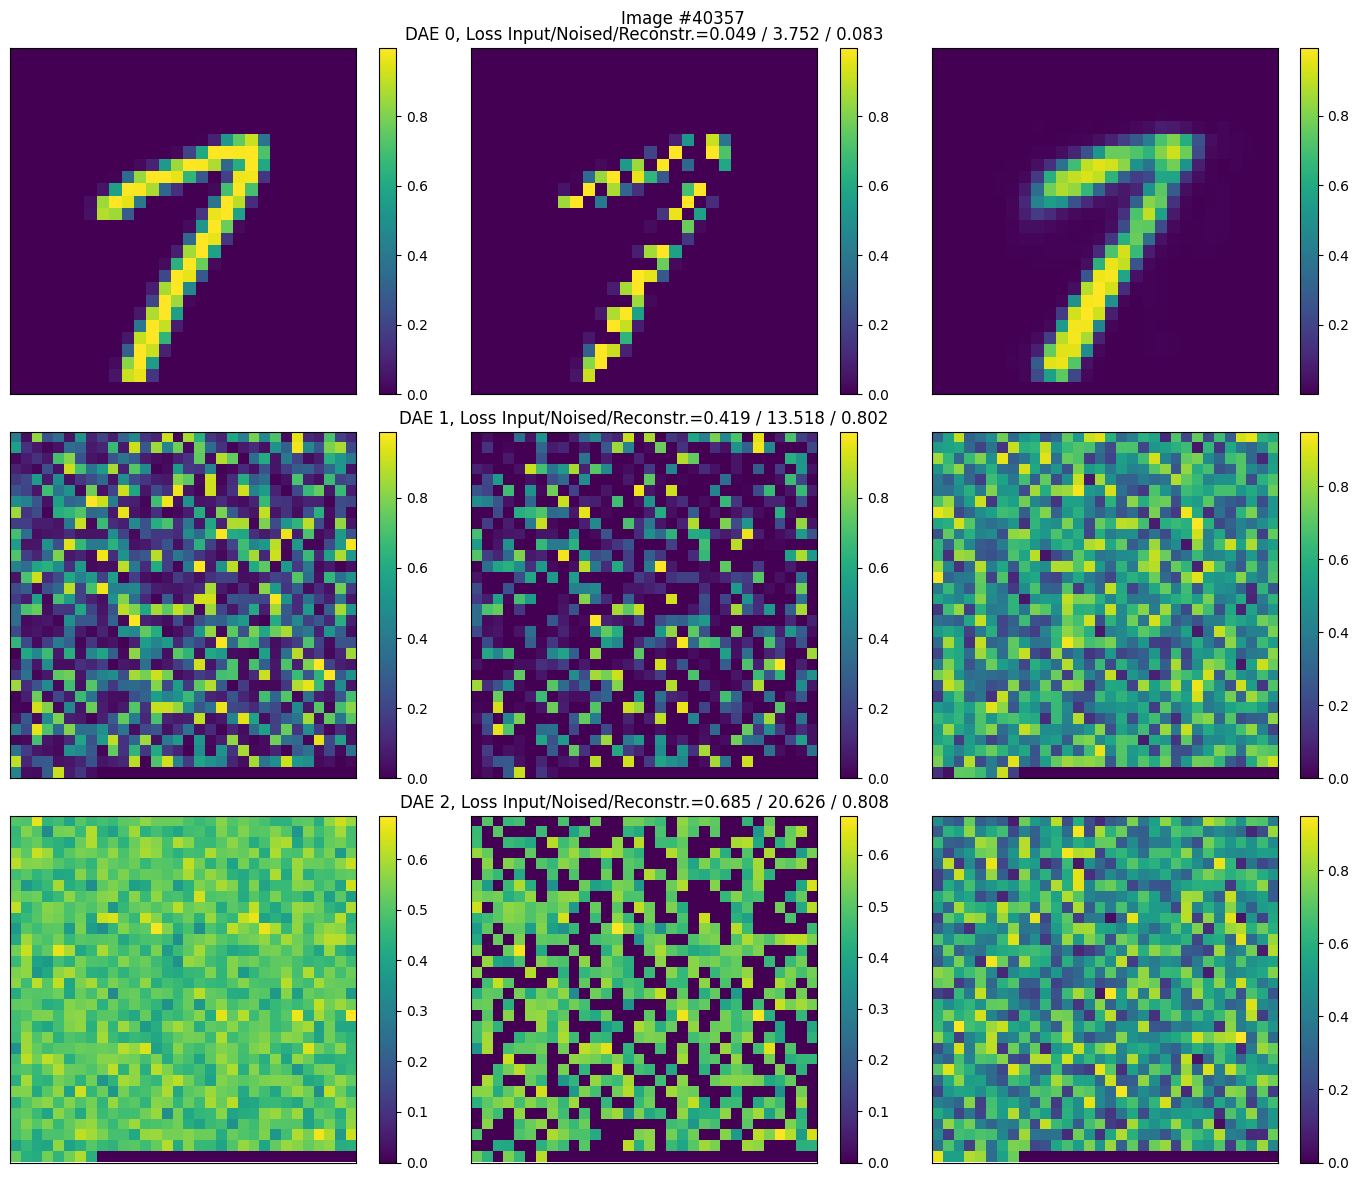

In [33]:
# @launchit.disable
fig, axes = plt.subplots(3, 3, subplot_kw={'yticks': [], 'xticks': []})
axes = axes.ravel()
fig.set_figwidth(14)
fig.set_figheight(4 * 3)

example_item_ind = RNG.choice(len(pretrain_dataset))
noise_func = noise_funcs[HP.pretraining.noise]
pretrain_model.eval()
loss_fn = losses[HP.pretraining.loss]()

with torch.no_grad():
    for target_dae_ind, base_ax_ind in zip(range(len(pretrain_model.daes)), range(len(axes))[::3]):
        batch = pretrain_dataset[example_item_ind].reshape(1, -1).to(CONFIG.cuda_device)
    
        for i in range(target_dae_ind):
            batch = pretrain_model.daes[i].encode(batch)

        noised = noise_func(batch)
        reconstructed, activations = pretrain_model.daes[target_dae_ind](noised)
        reconstructed = reconstructed.to(device='cpu').detach()
        noised = noised.to(device='cpu').detach()
        batch = batch.to(device='cpu')

        ax1, ax2, ax3 = axes[base_ax_ind], axes[base_ax_ind+1], axes[base_ax_ind+2]

        im = ax1.imshow(ArrayUtils.v2sm(batch.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax1)
        im = ax2.imshow(ArrayUtils.v2sm(noised.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax2)
        im = ax3.imshow(ArrayUtils.v2sm(reconstructed.numpy().ravel(), 0))
        fig.colorbar(im, ax=ax3)
        loss1 = compute_regularized_loss(batch, batch, activations, loss_fn, HP.pretraining.regularization)
        loss2 = compute_regularized_loss(noised, batch, activations, loss_fn, HP.pretraining.regularization)
        loss3 = compute_regularized_loss(reconstructed, batch, activations, loss_fn, HP.pretraining.regularization)
        ax2.set_title(f'DAE {target_dae_ind}, Loss Input/Noised/Reconstr.={loss1:.3f} / {loss2:.3f} / {loss3:.3f}');
        
fig.suptitle(f'Image #{example_item_ind}');
fig.tight_layout()

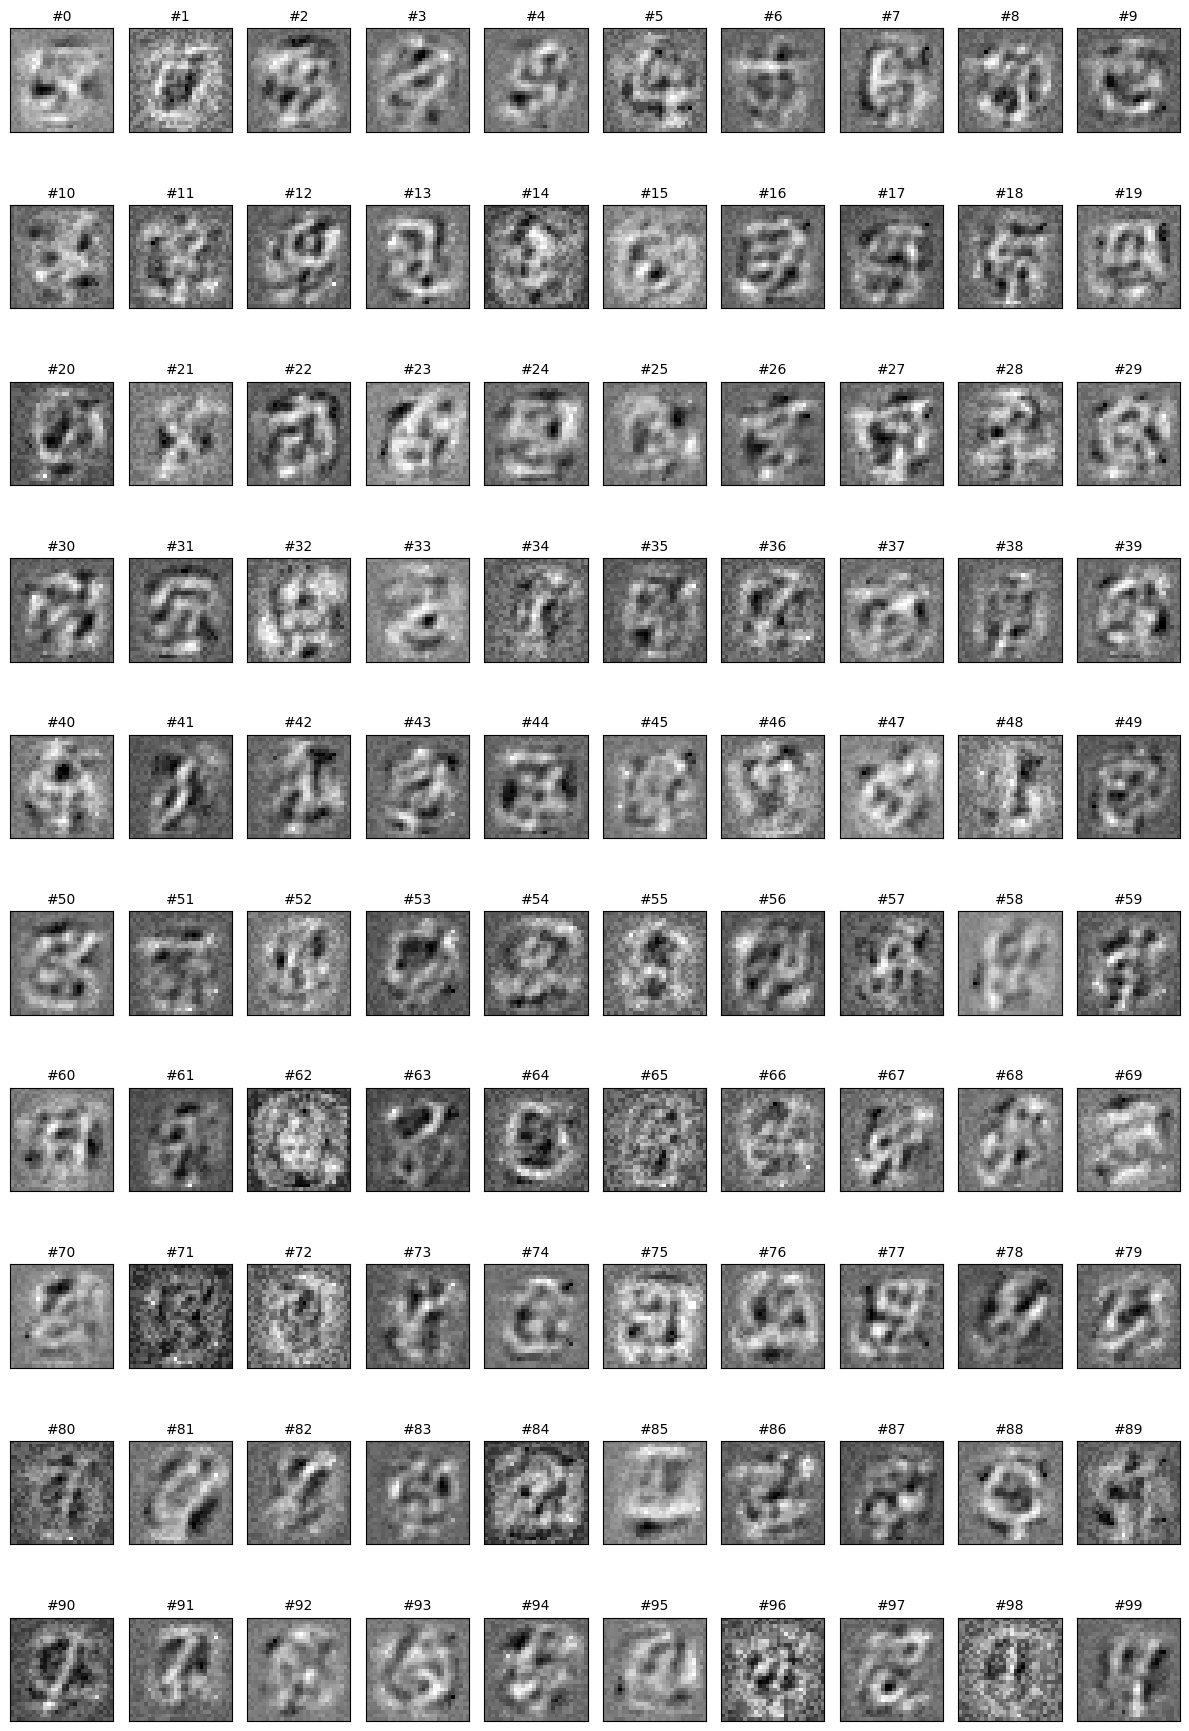

In [34]:
# @launchit.disable
bases_in_row = 10
max_filters_to_show = 100
fig, axes = plt.subplots(
    int(np.ceil(min(max_filters_to_show, pretrain_model.daes[0].encoder.out_features) / bases_in_row)), 
    bases_in_row,
    subplot_kw={'yticks': [], 'xticks': []}
)
fig.set_figwidth(12)
fig.set_figheight(18)
filters = pretrain_model.daes[0].encoder.weight.to(device='cpu').detach()

for i, (f, ax) in enumerate(zip(filters, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(ArrayUtils.v2sm(f), cmap='gray')

plt.tight_layout()

# Supervised training

Alternatively, as illustrated in Figure 4, a logistic regression layer can be added on top of the encoders, yielding a deep neural network amenable to supervised learning. The parameters of **all layers** can then be **simultaneously fine-tuned** using a gradient-based procedure such as stochastic gradient descent. 

## Dataset

In [67]:
def create_dataset_for_supervised_training(name, scaler):
    images, labels = get_mnist_images(name)
    images, scaler = preprocess_images(images, HP.images.preprocessing, scaler)
    images = torch.Tensor(images)
    images = images.contiguous() # force dense memory layout (speeds up DataLoader x2 in case of any transposes within preprocess_images)
    dataset = StackDataset(images, labels)
    return dataset, scaler

In [68]:
train_dataset, scaler = create_dataset_for_supervised_training('TRAIN', scaler=None)
test_dataset, _ = create_dataset_for_supervised_training('TEST', scaler=scaler)

## Model: DeepLinearRegression

In [69]:
class DeepLinearRegression(tnn.Module):
    def __init__(self, stacked_dae, classes_count):
        super().__init__()
        self.stacked_dae = stacked_dae
        self.linear_regression = tnn.Linear(stacked_dae.daes[-1].encoder.out_features, classes_count)

    def forward(self, inp):
        encoded = self.stacked_dae.encode(inp)
        return self.linear_regression(encoded)

In [70]:
model = DeepLinearRegression(pretrain_model, 10)
sum([p.numel() for p in model.parameters()])

2799794

## Training

In [71]:
optimizers = {
    'SGD': lambda parameters, lr: topt.SGD(parameters, lr),
    'Adam': lambda parameters, lr: topt.Adam(parameters, lr),
}

# @launchit.disable
# @launchit.collect
HP.training.batch_size = 100
HP.training.epochs_count = 100
HP.training.optimizer = 'Adam'
HP.training.learn_rate = 0.01
# @launchit.stop
pprint.pprint(HP._asdict())

{'images': {'preprocessing': 'UNINORM'},
 'pretrain_model': {'daes_count': 3,
                    'filters_count': 1000,
                    'is_bias': True,
                    'is_tied_weights': True,
                    'nonlinearity': {'decoder': 'sigmoid',
                                     'encoder': 'sigmoid'}},
 'pretraining': {'batch_size': 1000,
                 'epochs_count': 500,
                 'learn_rate': 0.01,
                 'loss': 'BCE',
                 'noise': 'Masking_0.4',
                 'optimizer': 'Adam',
                 'regularization': None},
 'training': {'batch_size': 100,
              'epochs_count': 100,
              'learn_rate': 0.01,
              'optimizer': 'Adam'}}


In [72]:
data_loader = DataLoader(train_dataset, batch_size=HP.training.batch_size, pin_memory=CONFIG.is_cuda, shuffle=True)
classes_count = 10
assert torch.all(train_labels.unique() == torch.arange(classes_count))
model = DeepLinearRegression(pretrain_model, classes_count)
loss_fn = tnn.CrossEntropyLoss()
optimizer = optimizers[HP.training.optimizer](model.parameters(), lr=HP.training.learn_rate)

In [ ]:
test_images = test_dataset.datasets[0].to(device=CONFIG.cuda_device)
test_labels = test_dataset.datasets[1].to(device=CONFIG.cuda_device)

for epoch_ind in tqdm(range(HP.training.epochs_count), 'Epoch'):
    epoch = epoch_ind + 1
    loss_train = 0
    
    for batch in data_loader:
        optimizer.zero_grad()
        
        images = batch[0].to(device=CONFIG.cuda_device)
        labels = batch[1].to(device=CONFIG.cuda_device)
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        
        optimizer.step()
        
        loss_train += loss.item() * len(batch)
    
    summary_writer.add_scalar('train_loss', loss_train / len(data_loader), epoch)

    with torch.no_grad():
        test_logits = model(test_images)
        test_loss = loss_fn(test_logits, test_labels)
        summary_writer.add_scalar('test_loss', test_loss, epoch)
    
    summary_writer.flush()

In [75]:
model_registry = new_model_registry()

with io.BytesIO() as b:
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'hypers': HP._asdict(),
    }, b)
    model_registry.attach_asset(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, b, 'train_pt', replace=True)

# Supervised SVC (classification)

## Pretrained model

In [24]:
# @launchit.disable
train_images, _ = get_mnist_images('TRAIN')
MODEL_INSTANCE_INFO = MODEL_INSTANCE_INFO._replace(version=2)
model_registry = new_model_registry(is_real=True)
meta = json.load(io.BytesIO(model_registry.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, 'meta')))
HP = Hyperparameters.from_dict(**meta['hypers'])
pprint.pprint(HP._asdict())
model = StackedDAE(train_images.shape[1], HP.stacked_dae)
model = model.to(device=CONFIG.cuda_device)
pt_data = model_registry.get_asset_content(MODEL_INSTANCE_INFO.name, MODEL_INSTANCE_INFO.version, 'pt')
pt_data = io.BytesIO(initial_bytes=pt_data)
checkpoint = torch.load(pt_data, map_location=torch.device(CONFIG.cuda_device))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

{'batch_size': 1000,
 'daes_count': 3,
 'dataset_preprocessing': 'UNINORM',
 'epochs_count': 500,
 'filters_count': 1000,
 'is_tied_weights': True,
 'learn_rate': 0.01,
 'loss': 'BCE_mean',
 'noise': 'Masking_0.4',
 'optimizer': 'Adam',
 'trained_dae_inds': '0,1,2'}


StackedDAE(
  (daes): ModuleList(
    (0): DenoiseAutoencoder(
      (encoder): Linear(in_features=784, out_features=1000, bias=True)
    )
    (1-2): 2 x DenoiseAutoencoder(
      (encoder): Linear(in_features=1000, out_features=1000, bias=True)
    )
  )
)

## Train & test datasets

In [25]:
# @launchit.disable
def create_dataset_for_classification(images, image_labels, model):
    features_list = []
    labels_list = []
    assert len(images) == len(image_labels)
    data_loader = DataLoader(list(zip(torch.Tensor(images), image_labels)), batch_size=100)
    
    for images, labels in tqdm(data_loader):
        images = torch.Tensor(images).to(device=CONFIG.cuda_device)
        
        with torch.no_grad():
            features = model.encode(images)
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    
    x = np.vstack(features_list).astype('float64') # float64 is recommended for SVC
    y = np.hstack(labels_list)
    return x, y

In [26]:
# @launchit.disable
train_images, train_image_labels = get_mnist_images('TRAIN')
train_images, train_images_scaler = preprocess_images(train_images, HP.images.preprocessing)
x_train, y_train = create_dataset_for_classification(train_images, train_image_labels, model)

  0%|          | 0/600 [00:00<?, ?it/s]

In [ ]:
# @launchit.disable
test_images, test_image_labels = get_mnist_images('TEST')
test_images, _ = preprocess_images(test_images, HP.images.preprocessing, train_images_scaler) # train_images_scaler is a must!!!
x_test, y_test = create_dataset_for_classification(test_images, test_image_labels, model)

## SVC

In [28]:
%%time
# @launchit.disable
random_state = 8231
n_jobs = None if CONFIG.is_cuml else -1 # using all CPUs (-1) showed to be a bad idea with CUML - no perf gain, but huge impact on CPU and GPU

# parameters = {'C': np.linspace(0.01, 1, 3), 'penalty': ['l1', 'l2'], 'max_iter': [100], 'random_state': [random_state]}
parameters = {'C': np.linspace(0.01, 1, 3), 'max_iter': [100], 'random_state': [random_state]}
search_svm = GridSearchCV(LinearSVC(), parameters, n_jobs=n_jobs)

# parameters = {'C': np.linspace(0.01, 1, 10), 'kernel': ['linear', 'rbf'], 'max_iter': [1000], 'random_state': [random_state]}
# parameters = {'C': np.linspace(3, 5, 5), 'gamma': np.linspace(0.01, 1, 5), 'kernel': ['rbf'], 'max_iter': [1000], 'random_state': [random_state]}
# search_svm = GridSearchCV(SVC(cache_size=1_000), parameters, n_jobs=n_jobs)

search_svm.fit(x_train, y_train)
svm = search_svm.best_estimator_
# vars(svm)

# svm = SVC(max_iter=300, kernel='rbf', C=1, cache_size=1_000, random_state=random_state) # version=2, 0.9772
# svm = SVC(max_iter=300, kernel='rbf', C=1.5, cache_size=1_000, random_state=random_state) # version=2, 0.9805
# svm = SVC(max_iter=300, kernel='rbf', C=4.555, cache_size=1_000, random_state=random_state) # version=2, 0.9808
# svm = SVC(max_iter=2_000, kernel='rbf', C=4.555, cache_size=1_000, random_state=random_state) # version=2, 0.9808
# svm = SVC(max_iter=100, kernel='rbf', C=3.8889, cache_size=1_000, random_state=random_state) # version=2, 0.9808
# svm.fit(x_train, y_train)

CPU times: user 46.2 s, sys: 1.23 s, total: 47.5 s
Wall time: 1min 57s


{'dual': 'auto',
 'tol': 0.0001,
 'C': np.float64(0.505),
 'multi_class': 'ovr',
 'fit_intercept': True,
 'intercept_scaling': 1,
 'class_weight': None,
 'verbose': 0,
 'random_state': 8231,
 'max_iter': 100,
 'penalty': 'l2',
 'loss': 'squared_hinge',
 'n_features_in_': 1000,
 'classes_': array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 'coef_': array([[-0.41556793,  0.05779941,  0.13622412, ..., -0.2026    ,
         -0.10577372,  0.13710795],
        [-0.16678968, -0.18609544, -0.06003702, ...,  0.06304661,
         -0.08960933, -0.06246719],
        [-0.73647787, -0.36252262,  0.34386448, ..., -0.19613223,
          0.29601313,  0.12040138],
        ...,
        [ 0.1052008 , -0.16385383, -0.03051754, ...,  0.00815348,
         -0.37845664, -0.4009994 ],
        [-0.31779411, -0.1235381 ,  0.09576726, ..., -0.41577996,
          0.73858333,  0.1688878 ],
        [ 0.25550595, -0.16910542, -0.28027716, ...,  0.29315293,
          0.9514011 ,  0.18120656]], shape=(10, 1000)),
 'intercept_': a

## SVC performance

In [72]:
%%time
# @launchit.disable
accuracy = svm.score(x_test, y_test)
print(f'Accuracy={accuracy}')

summary_log_dir = os.path.join(CONFIG.metrics_path, MODEL_INSTANCE_INFO.name, str(MODEL_INSTANCE_INFO.version))

with new_summary_writer(log_dir=summary_log_dir) as w:
    parameters = {
        'C': svm.C, 
        'max_iter': svm.max_iter, 
        'random_state': svm.random_state, 
    }
    
    if isinstance(svm, SVC):
        parameters['kernel'] = svm.kernel
        parameters['gamma'] = svm.gamma
    elif isinstance(svm, LinearSVC):
        parameters['penalty'] = svm.penalty
        
    w.add_hparams(
        parameters, 
        {'accuarcy': accuracy},
        run_name=f'{datetime.datetime.now().strftime('%y%m%d:%H%M%S')}')

CPU times: user 1min 9s, sys: 12.6 ms, total: 1min 9s
Wall time: 1min 9s


0.9805